### Fraud Detection System (Random Forest Classifier)
This project aims to develop a machine learning model to predict fraudulent credit card transactions by analyzing historical data, thereby protecting customers from unauthorized charges.

###Import Libraries
This cell imports the essential Python libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), and machine learning (sklearn).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### Mount Google Drive
This cell mounts Google Drive to access files stored in the cloud.

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### Load the Dataset
This cell loads the `CC Fraud.csv` dataset into a pandas DataFrame named `fraud` from Google Drive.

In [3]:
fraud_data = '/content/gdrive/MyDrive/CC Fraud.csv'
fraud = pd.read_csv(fraud_data)
fraud

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


### Create DataFrame and Display Head
This cell creates a new DataFrame `df_fraud` from the loaded data and displays its first few rows to verify successful loading.

In [4]:
df_fraud = pd.DataFrame(fraud)
df_fraud.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


### Data Quality Check
This cell performs an initial data quality check by displaying the shape of the DataFrame, its information (data types, non-null counts), and descriptive statistics.

In [5]:
display(df_fraud.shape)
display(df_fraud.info())
display(df_fraud.describe())

(1296675, 23)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

None

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


### Convert Transaction Date to Datetime
This cell converts the `trans_date_trans_time` column to datetime objects to enable time-based analysis.

In [6]:
df_fraud['trans_date_trans_time'] = pd.to_datetime(df_fraud['trans_date_trans_time'])
display(df_fraud.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Unnamed: 0             1296675 non-null  int64         
 1   trans_date_trans_time  1296675 non-null  datetime64[ns]
 2   cc_num                 1296675 non-null  int64         
 3   merchant               1296675 non-null  object        
 4   category               1296675 non-null  object        
 5   amt                    1296675 non-null  float64       
 6   first                  1296675 non-null  object        
 7   last                   1296675 non-null  object        
 8   gender                 1296675 non-null  object        
 9   street                 1296675 non-null  object        
 10  city                   1296675 non-null  object        
 11  state                  1296675 non-null  object        
 12  zip                    12966

None

### Verify Amount Column Type
This cell notes that the `amt` (amount) column is already in numeric format (float64) for numerical operations.

### Check for Missing Values
This cell checks for any missing values in the DataFrame to assess data completeness.

In [7]:
display(df_fraud.isnull().sum())

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


### Handle Duplicate Entries
This cell checks for and removes any duplicate rows in the DataFrame to ensure data uniqueness and integrity.

In [8]:
#Eliminate duplicate entries to ensure the uniqueness of the data (there were no duplicates)
print("Number of duplicate rows before removal:", df_fraud.duplicated().sum())

#Remove duplicate rows
df_fraud.drop_duplicates(inplace=True)

#Check for duplicate rows after removal
print("Number of duplicate rows after removal:", df_fraud.duplicated().sum())

#Display the shape of the cleaned dataframe after removing duplicates
display(df_fraud.shape)

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0


(1296675, 23)

### Count Fraudulent Transactions
This cell counts the occurrences of fraudulent (1) and non-fraudulent (0) transactions in the `is_fraud` column.

In [9]:
display(df_fraud['is_fraud'].value_counts())

,count
is_fraud,
0,1289169
1,7506


### Distribution of Transaction Amounts
This cell generates a histogram to visualize the distribution of transaction amounts, helping to identify common transaction sizes and potential outliers.

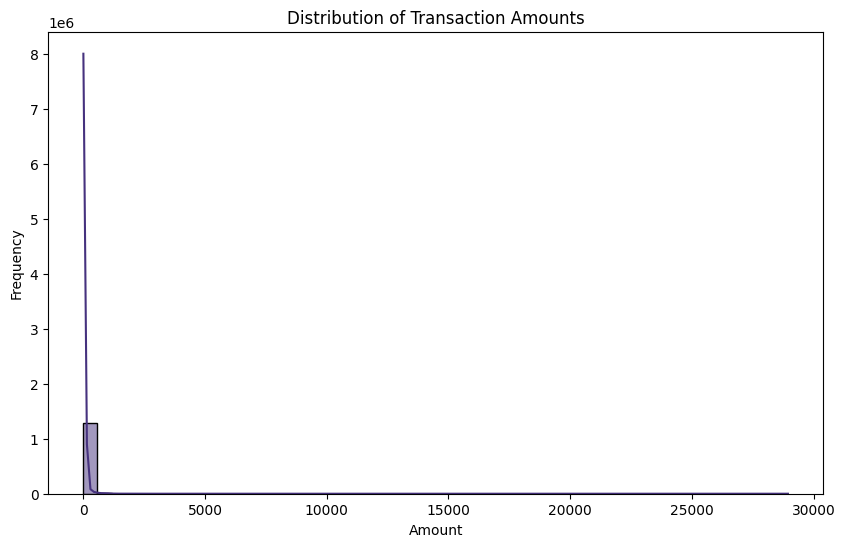

Most transactions are smaller in amount.


In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df_fraud['amt'], bins=50, kde=True, color=sns.color_palette('viridis')[0])
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()
print("Most transactions are smaller in amount.")

### Boxplot of Transaction Amounts
This cell creates a boxplot to visualize outliers in the transaction amounts.

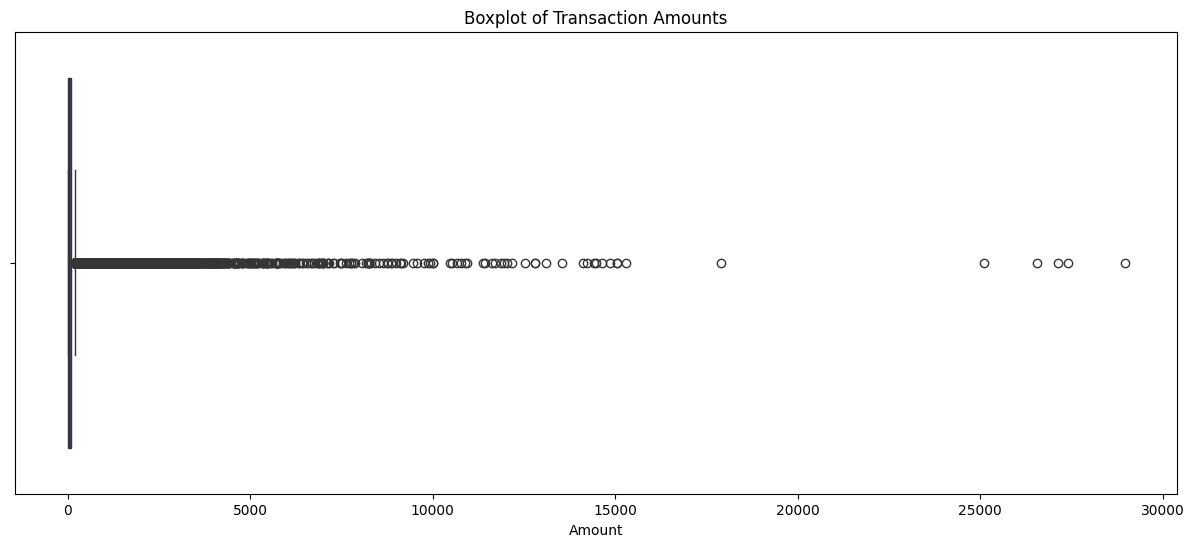

There are a small number of true outliers, but are they fraudulent or not?


In [11]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=df_fraud['amt'], color=sns.color_palette('viridis')[0])
plt.title('Boxplot of Transaction Amounts')
plt.xlabel('Amount')
plt.show()
print("There are a small number of true outliers, but are they fraudulent or not?")

### Log-Scaled Boxplot of Transaction Amounts
This cell generates a boxplot with a logarithmic scale on the x-axis to better visualize the distribution of transaction amounts, especially the smaller values.

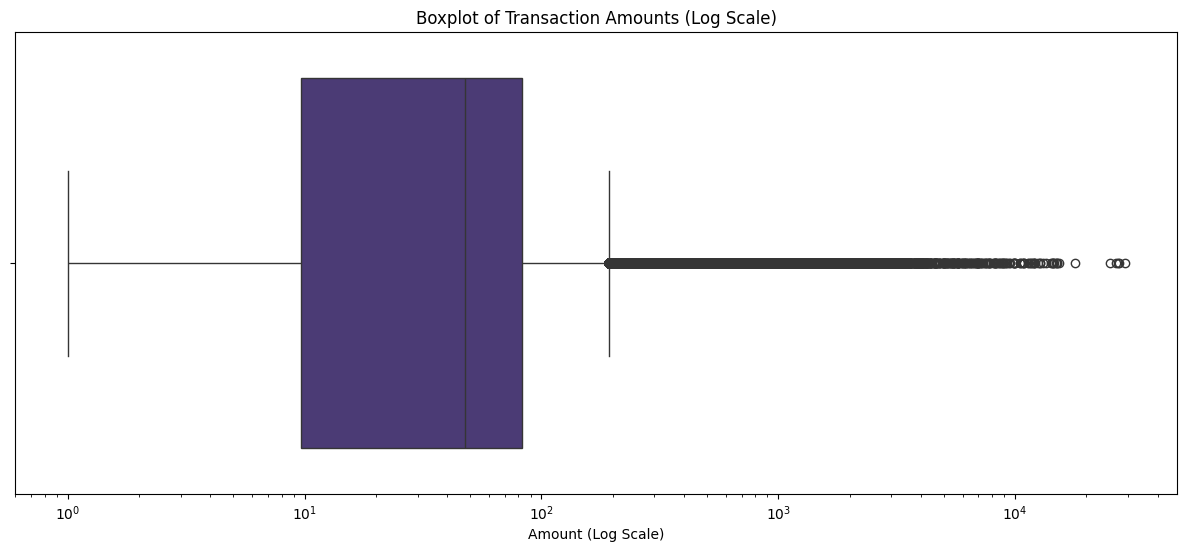

In [12]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=df_fraud['amt'], color=sns.color_palette('viridis')[0])
plt.title('Boxplot of Transaction Amounts (Log Scale)')
plt.xlabel('Amount (Log Scale)')

#Apply logarithmic scale to the x-axis for a better visualization
plt.xscale('log')
plt.show()

### Analyze High-Value Transactions (95th Percentile)
This cell filters and displays transactions with amounts above the 95th percentile to specifically examine high-value transactions.

In [13]:
high_amount_threshold = df_fraud['amt'].quantile(0.95)
high_amount_transactions = df_fraud[df_fraud['amt'] > high_amount_threshold]

print(f"Filtering transactions with amount greater than {high_amount_threshold:.2f} (95th percentile).")
display(high_amount_transactions.head())
display(high_amount_transactions.shape)

Filtering transactions with amount greater than 196.31 (95th percentile).


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
9,9,2019-01-01 00:06:01,2720830304681674,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,198.39,Melissa,Aguilar,F,21326 Taylor Squares Suite 708,...,36.5220,-87.3490,151785,Pathologist,1974-03-28,3b9014ea8fb80bd65de0b1463b00b00e,1325376361,37.179198,-87.485381,0
16,16,2019-01-01 00:10:49,6011860238257910,fraud_Lebsack and Sons,misc_net,327.00,Lisa,Mendez,F,44259 Beth Station Suite 215,...,36.3850,-98.0727,1078,"Programme researcher, broadcasting/film/video",1952-07-06,991c04803b4d4eeab30d6245a872e3d3,1325376649,36.384092,-99.048472,0
17,17,2019-01-01 00:10:58,3565423334076143,fraud_Mayert Group,shopping_pos,341.67,Nathan,Thomas,M,4923 Campbell Pines Suite 717,...,38.9763,-87.3667,4081,Energy engineer,1938-03-15,f12cf52be2175703db789a4644c32f25,1325376658,38.674491,-88.305767,0
36,36,2019-01-01 00:26:22,3598215285024754,fraud_Heidenreich PLC,grocery_pos,207.36,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,f246ac27c09429ff1e385d4683c79c4d,1325377582,40.202538,-73.859212,0


(64822, 23)

### Fraud Count in High-Value Transactions
This cell displays the count of fraudulent versus non-fraudulent transactions within the previously filtered high-value transactions (95th percentile).

In [14]:
display(high_amount_transactions['is_fraud'].value_counts())

,count
is_fraud,
0,59117
1,5705


### Analyze High-Value Transactions (90th Percentile)
This cell filters and displays transactions with amounts above the 90th percentile to further investigate high-value transactions, expanding the scope from the 95th percentile.

In [15]:
#Include 5% more transactions down into the 90th percentile to search for more high value fraud transactions
ninety_amount_threshold = df_fraud['amt'].quantile(0.90)
ninety_amount_transactions = df_fraud[df_fraud['amt'] > ninety_amount_threshold]

print(f"Filtering transactions with amount greater than {ninety_amount_threshold:.2f} (90th percentile).")
display(ninety_amount_transactions.head())
display(ninety_amount_transactions.shape)

Filtering transactions with amount greater than 136.67 (90th percentile).


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
9,9,2019-01-01 00:06:01,2720830304681674,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,198.39,Melissa,Aguilar,F,21326 Taylor Squares Suite 708,...,36.5220,-87.3490,151785,Pathologist,1974-03-28,3b9014ea8fb80bd65de0b1463b00b00e,1325376361,37.179198,-87.485381,0
16,16,2019-01-01 00:10:49,6011860238257910,fraud_Lebsack and Sons,misc_net,327.00,Lisa,Mendez,F,44259 Beth Station Suite 215,...,36.3850,-98.0727,1078,"Programme researcher, broadcasting/film/video",1952-07-06,991c04803b4d4eeab30d6245a872e3d3,1325376649,36.384092,-99.048472,0
17,17,2019-01-01 00:10:58,3565423334076143,fraud_Mayert Group,shopping_pos,341.67,Nathan,Thomas,M,4923 Campbell Pines Suite 717,...,38.9763,-87.3667,4081,Energy engineer,1938-03-15,f12cf52be2175703db789a4644c32f25,1325376658,38.674491,-88.305767,0
36,36,2019-01-01 00:26:22,3598215285024754,fraud_Heidenreich PLC,grocery_pos,207.36,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,f246ac27c09429ff1e385d4683c79c4d,1325377582,40.202538,-73.859212,0


(129658, 23)

### Fraud Count in Extended High-Value Transactions
This cell displays the count of fraudulent versus non-fraudulent transactions within the extended set of high-value transactions (90th percentile).

In [16]:
display(ninety_amount_transactions['is_fraud'].value_counts())
print("90th percentile included only 19 more fraudulent transactions.")

,count
is_fraud,
0,123934
1,5724


90th percentile included only 19 more fraudulent transactions.


### Analyze Fraud by Category and Merchant
This cell analyzes and displays the distribution of fraudulent transactions by `category` and the top 10 `merchant` with the most fraudulent activities.

In [17]:
fraud_by_category = df_fraud[df_fraud['is_fraud'] == 1]['category'].value_counts()
print("Fraudulent transactions by category:")
display(fraud_by_category)

fraud_by_merchant = df_fraud[df_fraud['is_fraud'] == 1]['merchant'].value_counts()
print("\nFraudulent transactions by merchant (Top 10):")
display(fraud_by_merchant.head(10))

Fraudulent transactions by category:


,count
category,
grocery_pos,1743
shopping_net,1713
misc_net,915
shopping_pos,843
gas_transport,618
misc_pos,250
kids_pets,239
entertainment,233
personal_care,220



Fraudulent transactions by merchant (Top 10):


,count
merchant,
fraud_Rau and Sons,49
fraud_Kozey-Boehm,48
fraud_Cormier LLC,48
fraud_Doyle Ltd,47
fraud_Kilback LLC,47
fraud_Vandervort-Funk,47
fraud_Padberg-Welch,44
fraud_Kuhn LLC,44
fraud_Terry-Huel,43


### Bar Plot of Fraudulent Transactions by Category
This cell generates a bar plot visualizing the number of fraudulent transactions across different categories.

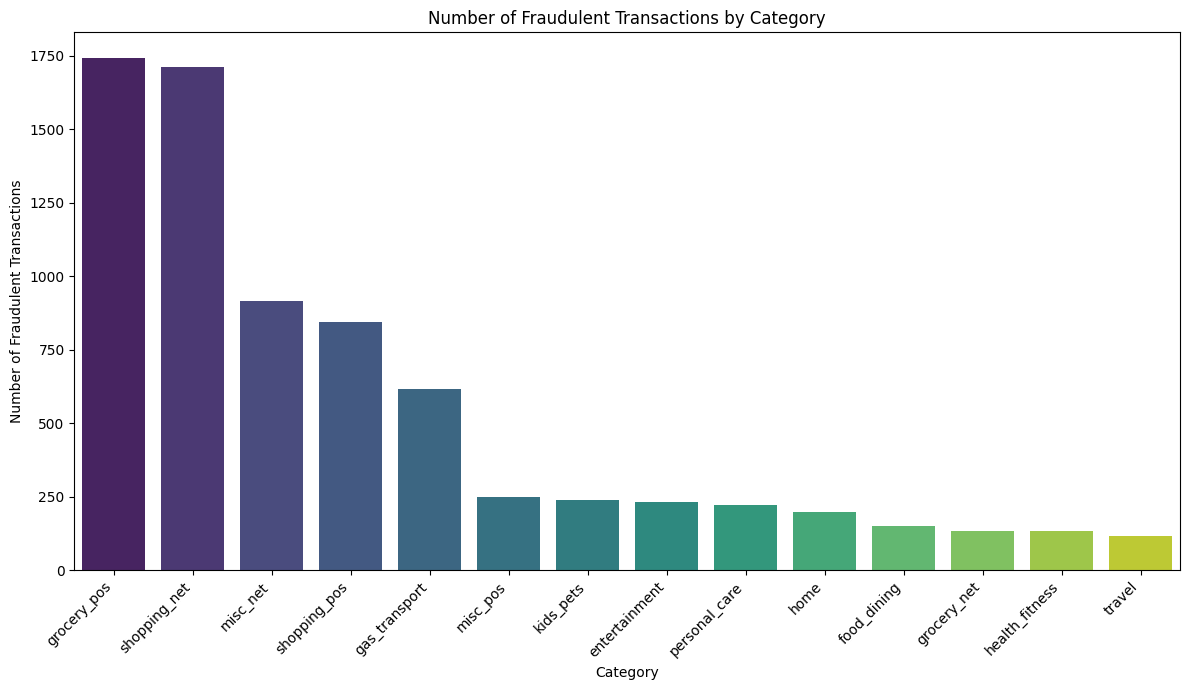

In [18]:
plt.figure(figsize=(12, 7))
sns.barplot(x=fraud_by_category.index, y=fraud_by_category.values, hue=fraud_by_category.index, palette='viridis', legend=False)
plt.title('Number of Fraudulent Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bar Plot of Top 10 Fraudulent Merchants
This cell generates a bar plot visualizing the top 10 merchants with the highest number of fraudulent transactions.

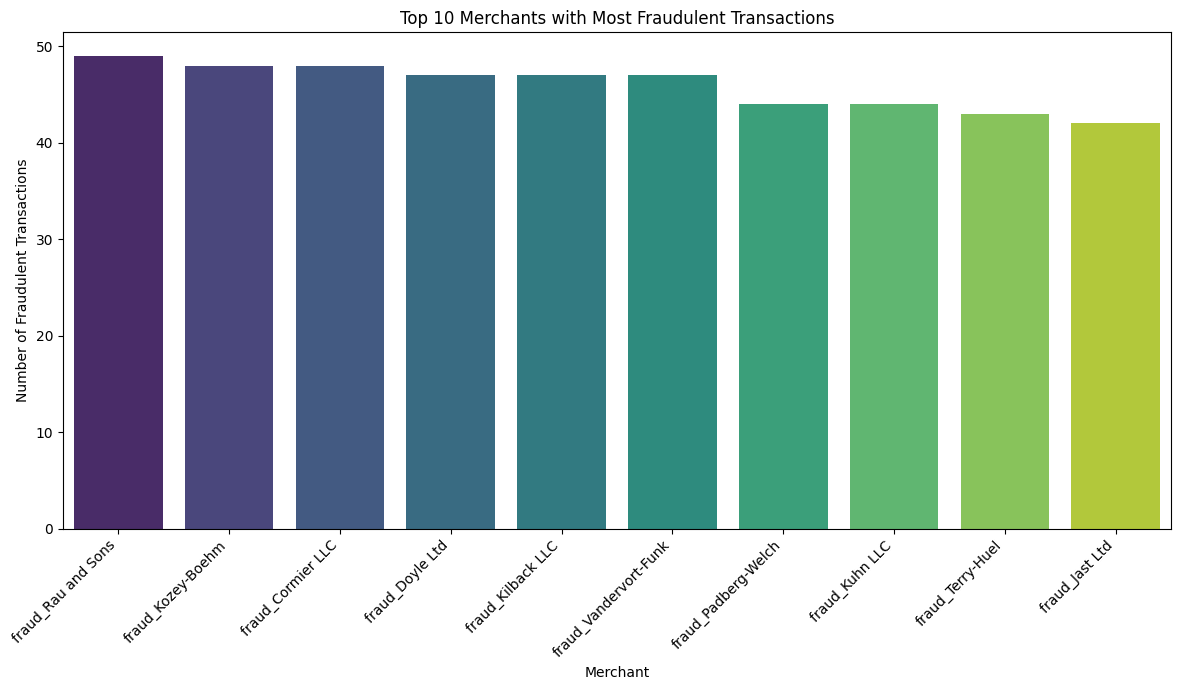

In [19]:
plt.figure(figsize=(12, 7))
sns.barplot(x=fraud_by_merchant.head(10).index, y=fraud_by_merchant.head(10).values, hue=fraud_by_merchant.head(10).index, palette='viridis', legend=False)
plt.title('Top 10 Merchants with Most Fraudulent Transactions')
plt.xlabel('Merchant')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Boxplot of Transaction Amounts (Fraud vs. Non-Fraud)
This cell creates a boxplot to compare the distribution of transaction amounts between fraudulent and non-fraudulent transactions, using a logarithmic scale for better visualization.

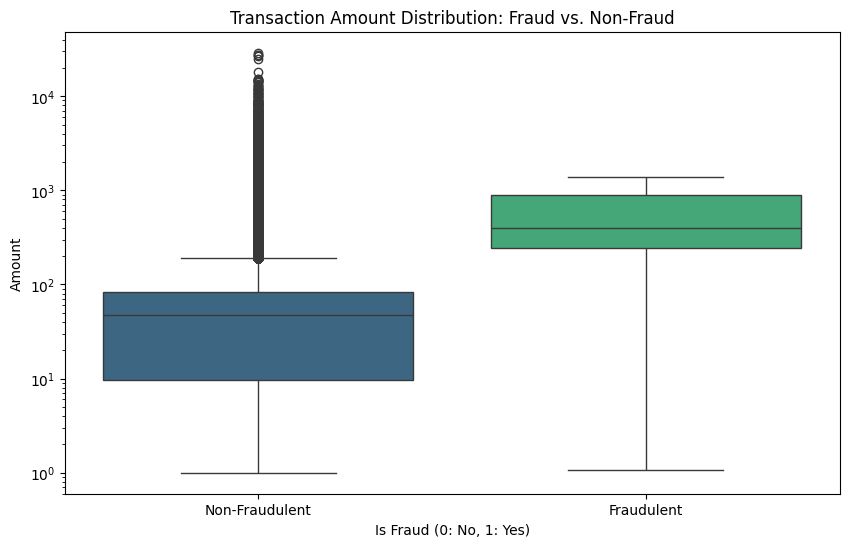

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='amt', data=df_fraud, palette='viridis', hue='is_fraud', legend=False)
plt.title('Transaction Amount Distribution: Fraud vs. Non-Fraud')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Amount')
plt.xticks([0, 1], ['Non-Fraudulent', 'Fraudulent'])
plt.yscale('log') #Use log scale due to large range of amounts
plt.show()

### Top 50 Highest Value Fraudulent Transactions
This cell identifies and displays the top 50 fraudulent transactions with the highest amounts, along with relevant details like category, merchant, and location.

In [21]:
#Filter for fraudulent transactions
fraudulent_transactions = df_fraud[df_fraud['is_fraud'] == 1]

#View the top 50 largest transactions
top_50_high_value_fraud = fraudulent_transactions.sort_values(by='amt', ascending=False).head(50)

#Display relevant location information for the top 50
print("Top 50 Highest Value Fraudulent Transactions:")
display(top_50_high_value_fraud[['amt', 'category', 'merchant', 'city', 'state', 'street']])

Top 50 Highest Value Fraudulent Transactions:


,amt,category,merchant,city,state,street
1262544,1376.04,shopping_pos,fraud_Kuhn LLC,Queen Anne,MD,10376 Bullock Rapid
514148,1371.81,shopping_pos,fraud_Metz-Boehm,Tekoa,WA,0110 Ashley Forest
30239,1334.07,shopping_pos,fraud_Pouros-Conroy,Edisto Island,SC,6983 Carrillo Isle
1258483,1324.80,shopping_pos,"fraud_Watsica, Haag and Considine",Queen Anne,MD,10376 Bullock Rapid
821435,1313.18,shopping_pos,fraud_Denesik and Sons,Karns City,PA,5124 Wendy Skyway Suite 154
1258594,1312.98,shopping_net,fraud_Jast Ltd,Queen Anne,MD,10376 Bullock Rapid
872879,1294.83,shopping_net,"fraud_Heathcote, Yost and Kertzmann",Oconto Falls,WI,586 Thomas Cliffs
75418,1292.21,shopping_net,fraud_Schumm PLC,Hovland,MN,15315 Vaughn Park Suite 356
531246,1289.89,shopping_net,"fraud_Heathcote, Yost and Kertzmann",Dayton,OH,01505 Amy Stravenue
878175,1289.07,shopping_net,fraud_Schmidt and Sons,North East,PA,95017 Kevin Expressway


### Fraudulent Transactions by Hour of Day
This cell extracts the hour from the transaction timestamp for fraudulent transactions and counts their occurrences by hour, which is a feature engineering step.

In [22]:
#Feature Engineering
#Filter for fraudulent transactions
fraudulent_transactions = df_fraud[df_fraud['is_fraud'] == 1].copy()

#Extract the hour of the day
fraudulent_transactions['transaction_hour'] = fraudulent_transactions['trans_date_trans_time'].dt.hour

#Count fraudulent transactions by hour
fraud_by_hour = fraudulent_transactions['transaction_hour'].value_counts().sort_index()

print("Fraudulent transactions by hour of the day:")
display(fraud_by_hour)

Fraudulent transactions by hour of the day:


,count
transaction_hour,
0,635
1,658
2,625
3,609
4,46
5,60
6,40
7,56
8,49


### Bar Plot of Fraudulent Transactions by Hour
This cell generates a bar plot to visualize the distribution of fraudulent transactions throughout the hours of the day, highlighting peak times for fraud.

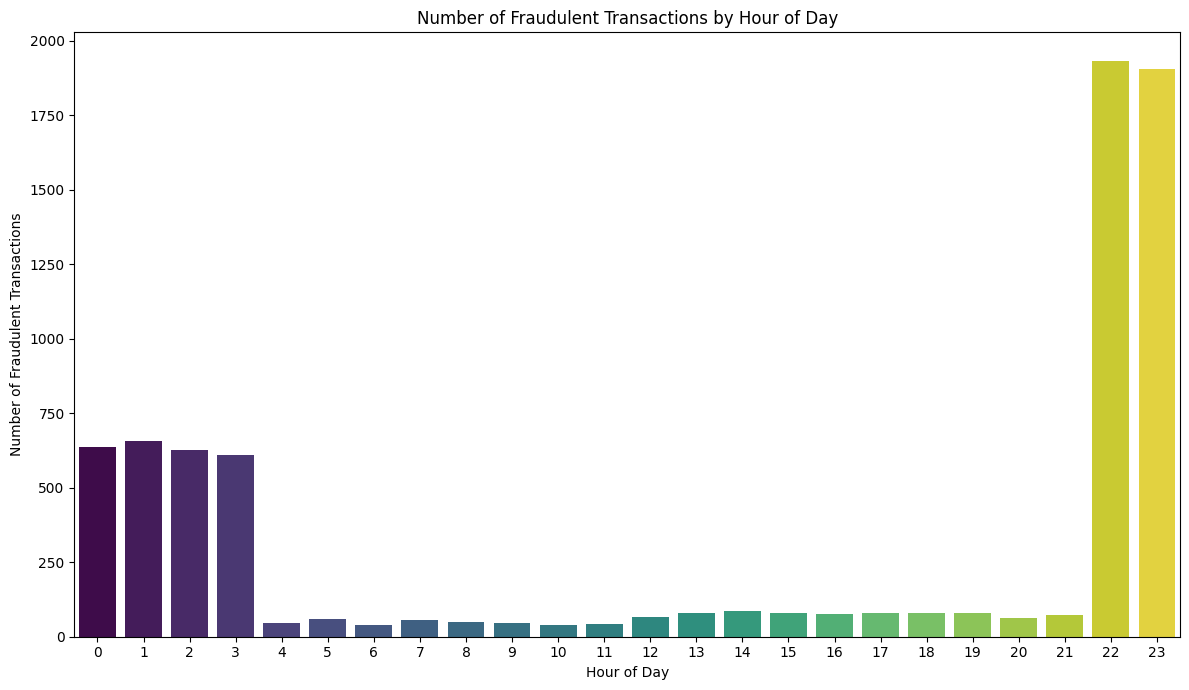

Most fraud happens between 10:00pm and 3:00am (2200-0300hrs), peaking at 10:00pm.


In [23]:
plt.figure(figsize=(12, 7))
sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values, hue=fraud_by_hour.index, palette='viridis', legend=False)
plt.title('Number of Fraudulent Transactions by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Most fraud happens between 10:00pm and 3:00am (2200-0300hrs), peaking at 10:00pm.")

### Geographical Distribution of Fraudulent Transactions
This cell generates a scatter plot to visualize the geographical locations (latitude and longitude) where fraudulent transactions occur.

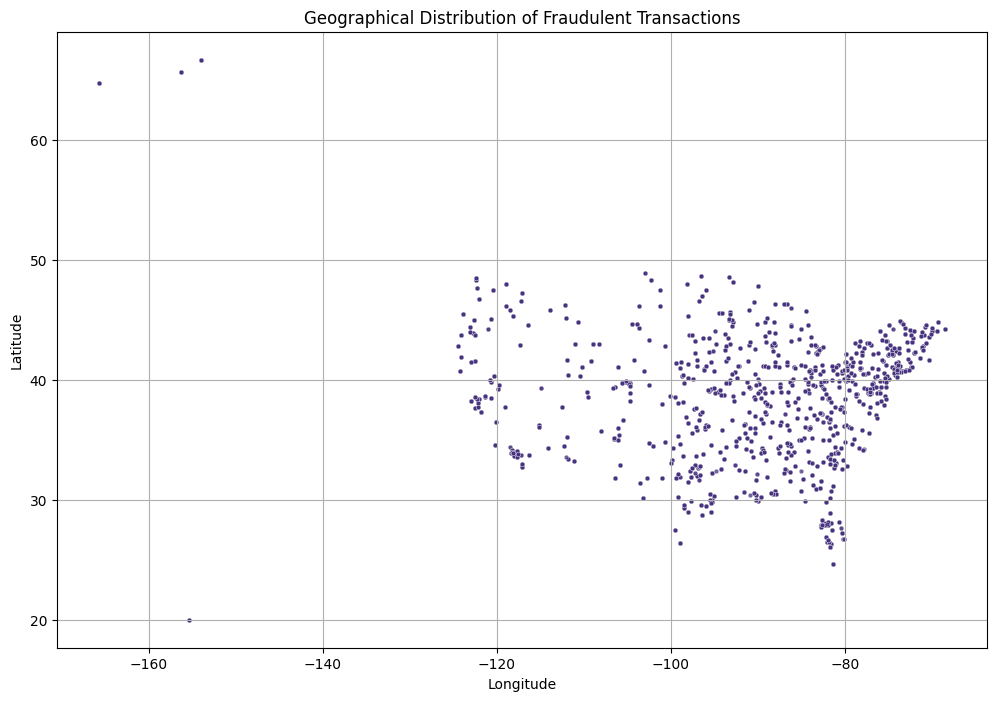

In [24]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='long', y='lat', data=fraudulent_transactions, alpha=0.5, s=10, color=sns.color_palette('viridis')[0])
plt.title('Geographical Distribution of Fraudulent Transactions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

### Fraudulent Transactions by State
This cell identifies and visualizes the number of fraudulent transactions occurring in each state using a bar plot.

Fraudulent transactions by state:


,count
state,
NY,555
TX,479
PA,458
CA,326
OH,321
FL,281
IL,248
MI,238
AL,215


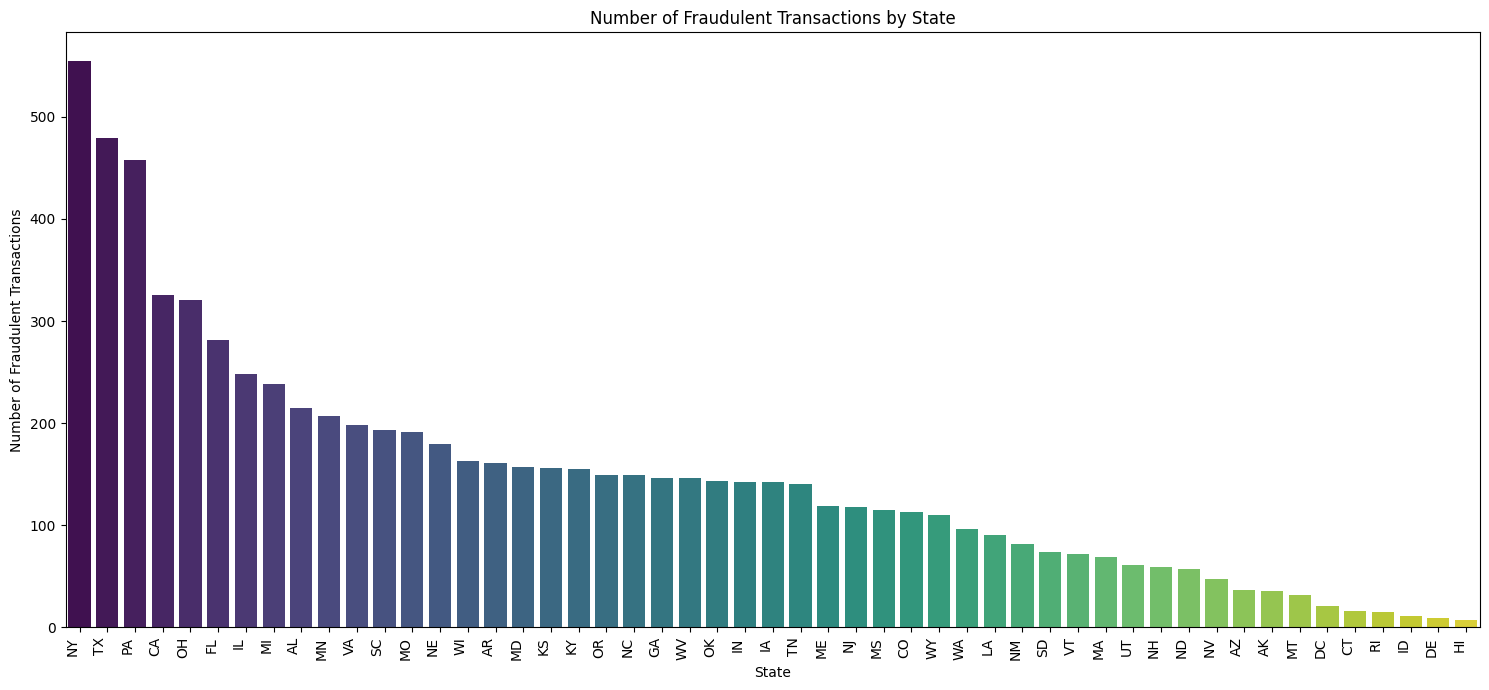

In [25]:
#Filter for fraudulent transactions
fraudulent_transactions = df_fraud[df_fraud['is_fraud'] == 1]

#Count fraudulent transactions by state
fraud_by_state = fraudulent_transactions['state'].value_counts()

print("Fraudulent transactions by state:")
display(fraud_by_state)

#Bar plot of fraudulent transactions by state
plt.figure(figsize=(15, 7))
sns.barplot(x=fraud_by_state.index, y=fraud_by_state.values, hue=fraud_by_state.index, palette='viridis', legend=False)
plt.title('Number of Fraudulent Transactions by State')
plt.xlabel('State')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

### Drop Irrelevant Columns
This cell prepares the data for modeling by dropping columns that are not useful for prediction, such as identifiers and personal information, to create `df_fraud_processed`.

In [26]:
columns_to_drop = ['Unnamed: 0', 'cc_num', 'first', 'last', 'trans_num', 'unix_time', 'dob']
df_fraud_processed = df_fraud.drop(columns=columns_to_drop)

#Display the updated DataFrame information
display(df_fraud_processed.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 16 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   merchant               1296675 non-null  object        
 2   category               1296675 non-null  object        
 3   amt                    1296675 non-null  float64       
 4   gender                 1296675 non-null  object        
 5   street                 1296675 non-null  object        
 6   city                   1296675 non-null  object        
 7   state                  1296675 non-null  object        
 8   zip                    1296675 non-null  int64         
 9   lat                    1296675 non-null  float64       
 10  long                   1296675 non-null  float64       
 11  city_pop               1296675 non-null  int64         
 12  job                    12966

None

### Separate Features and Target Variable
This cell separates the dataset into features (X), which are the input variables for the model, and the target variable (y), which is `is_fraud`.

In [27]:
X = df_fraud_processed.drop('is_fraud', axis=1)
y = df_fraud_processed['is_fraud']

display(X.head())
display(y.head())
display(X.shape)
display(y.shape)

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",36.011293,-82.048315
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,49.159047,-118.186462
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,43.150704,-112.154481
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,47.034331,-112.561071
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,38.674999,-78.632459


,is_fraud
0,0
1,0
2,0
3,0
4,0


(1296675, 15)

(1296675,)

### One-Hot Encode Categorical Features
This cell identifies categorical columns and applies one-hot encoding to convert them into a numerical format suitable for machine learning models.

In [28]:
#Transform the Data
#Identify object columns
object_cols = X.select_dtypes(include='object').columns
print("Object columns to encode:", object_cols)

#One-hot encode object columns
X_encoded = pd.get_dummies(X, columns=object_cols, dummy_na=False)

display(X_encoded.head())
display(X_encoded.shape)

Object columns to encode: Index(['merchant', 'category', 'gender', 'street', 'city', 'state', 'job'], dtype='object')


,trans_date_trans_time,amt,zip,lat,long,city_pop,merch_lat,merch_long,merchant_fraud_Abbott-Rogahn,merchant_fraud_Abbott-Steuber,...,job_Visual merchandiser,job_Volunteer coordinator,job_Warden/ranger,job_Warehouse manager,job_Waste management officer,job_Water engineer,job_Water quality scientist,job_Web designer,job_Wellsite geologist,job_Writer
0,2019-01-01 00:00:18,4.97,28654,36.0788,-81.1781,3495,36.011293,-82.048315,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2019-01-01 00:00:44,107.23,99160,48.8878,-118.2105,149,49.159047,-118.186462,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2019-01-01 00:00:51,220.11,83252,42.1808,-112.2620,4154,43.150704,-112.154481,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2019-01-01 00:01:16,45.00,59632,46.2306,-112.1138,1939,47.034331,-112.561071,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2019-01-01 00:03:06,41.96,24433,38.4207,-79.4629,99,38.674999,-78.632459,False,False,...,False,False,False,False,False,False,False,False,False,False


(1296675, 3139)

### Scale Numerical Features
This cell scales the numerical features in the dataset using `StandardScaler` to normalize their range, which can improve model performance.

In [29]:
#Identify numerical columns (exclude datetime and boolean columns after one-hot encoding)
numerical_cols = X_encoded.select_dtypes(include=np.number).columns

#Initialize StandardScaler
scaler = StandardScaler()

#Scale the numerical columns
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

display(X_encoded.head())

,trans_date_trans_time,amt,zip,lat,long,city_pop,merch_lat,merch_long,merchant_fraud_Abbott-Rogahn,merchant_fraud_Abbott-Steuber,...,job_Visual merchandiser,job_Volunteer coordinator,job_Warden/ranger,job_Warehouse manager,job_Waste management officer,job_Water engineer,job_Water quality scientist,job_Web designer,job_Wellsite geologist,job_Writer
0,2019-01-01 00:00:18,-0.407826,-0.749136,-0.484420,0.657620,-0.282589,-0.494354,0.593864,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2019-01-01 00:00:44,0.230039,1.872567,2.039120,-2.033870,-0.293670,2.078699,-2.030341,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2019-01-01 00:00:51,0.934149,1.281042,0.717754,-1.601537,-0.280406,0.902849,-1.592323,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2019-01-01 00:01:16,-0.158132,0.402753,1.515617,-1.590766,-0.287742,1.662886,-1.621848,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2019-01-01 00:03:06,-0.177094,-0.906090,-0.023035,0.782279,-0.293835,0.026941,0.841909,False,False,...,False,False,False,False,False,False,False,False,False,False


### Split Data into Training and Testing Sets
This cell splits the preprocessed data into training and testing sets using `train_test_split` to prepare for model training and evaluation.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, train_size=0.8, test_size=0.2, random_state=42, stratify=y)

print("Shape of training data (X_train, y_train):", X_train.shape, y_train.shape)
print("Shape of testing data (X_test, y_test):", X_test.shape, y_test.shape)

Shape of training data (X_train, y_train): (1037340, 3139) (1037340,)
Shape of testing data (X_test, y_test): (259335, 3139) (259335,)


### Train Random Forest Classifier
This cell initializes and trains a `RandomForestClassifier` model using the training data, after dropping the `trans_date_trans_time` column.

In [31]:
#Initialize the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

#Drop the datetime column
X_train = X_train.drop('trans_date_trans_time', axis=1)
X_test = X_test.drop('trans_date_trans_time', axis=1)

#Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Evaluate Model Performance
This cell evaluates the trained Random Forest model's performance on the test set by calculating accuracy, precision, recall, F1 score, and generating a confusion matrix.

In [32]:
#Make predictions on the test set
y_pred = rf_model.predict(X_test)

#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.9974
Precision: 0.8868
Recall: 0.6262
F1 Score: 0.7341
Confusion Matrix:
 [[257714    120]
 [   561    940]]


### Visualize Confusion Matrix
This cell visualizes the confusion matrix generated from the model evaluation using a heatmap, providing a clear representation of true positives, true negatives, false positives, and false negatives.

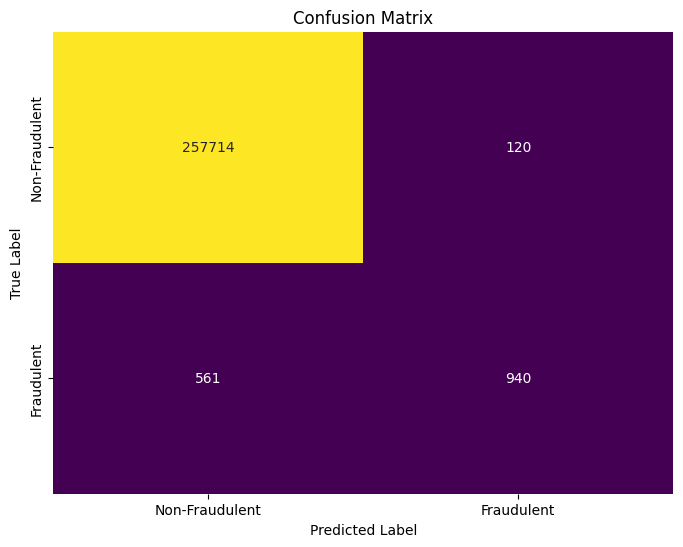

In [33]:
#Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis', cbar=False,
            xticklabels=['Non-Fraudulent', 'Fraudulent'],
            yticklabels=['Non-Fraudulent', 'Fraudulent'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Random Forest Model Results Summary

The Random Forest Classifier was trained and evaluated to predict fraudulent transactions. Here's a summary of its performance:

- **Accuracy**: 0.9974 (The model correctly classified approximately 99.74% of all transactions, both fraudulent and non-fraudulent).
- **Precision**: 0.8868 (Out of all transactions predicted as fraudulent, 88.68% were actually fraudulent).
- **Recall**: 0.6262 (The model successfully identified 62.62% of all actual fraudulent transactions).
- **F1 Score**: 0.7341 (The F1-score provides a balance between precision and recall, indicating a reasonably good performance in classifying fraud).

**Confusion Matrix Analysis:**

```
[[257714    120]
 [   561    940]]
```

- **True Negatives (TN): 257,714** (Correctly identified non-fraudulent transactions).
- **False Positives (FP): 120** (Non-fraudulent transactions incorrectly predicted as fraudulent, also known as Type I error).
- **False Negatives (FN): 561** (Fraudulent transactions incorrectly predicted as non-fraudulent, also known as Type II error).
- **True Positives (TP): 940** (Correctly identified fraudulent transactions).

The confusion matrix highlights that while the model has a very high overall accuracy (due to the imbalanced dataset where most transactions are non-fraudulent), there's a significant number of fraudulent transactions (561) that the model failed to detect. This indicates a potential area for improvement, possibly by tuning the model to prioritize recall or by using techniques for imbalanced datasets.